# Week 4 Day 1 — ML Foundations
## Problem Framing, Hold-Out Test & Baseline
**Dataset:** UCI "Adult" (Census Income) — predicting whether an individual earns **>$50K/year**

---

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              ConfusionMatrixDisplay)

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 400
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

---
## Task 1: Problem Definition & Success Metric

**Problem Statement:**

The objective is to build a binary classification model that predicts whether an individual's annual income exceeds 50,000, using demographic, educational, and employment-related features from the U.S. Census Adult dataset. The positive class represents individuals earning more than $50,000 per year.

**Target definition:** `income > 50K` = positive class (1), `income <= 50K` = negative class (0).

**Business objective:** This mirrors a targeted marketing / premium-offer screening problem — e.g. a
financial services company wants to identify likely high-income individuals to target with a premium
credit card or investment product offer. Each outreach (call, mailer, ad) costs money and a poor
targeting list annoys low-value leads and wastes budget. So the business cares most about **not wasting
outreach on people who won't qualify/convert** — i.e. when the model says "target this person," it
should usually be right.

**Chosen primary metric: Precision** (with F1 and ROC AUC reported as supporting metrics).

#Choose the Primary Evaluation Metric

For this project, we choose Precision.

#Why Precision?

The business objective is targeted marketing. False Positives mean:

marketing budget wasted
unnecessary outreach
reduced campaign efficiency

A model with high precision ensures that most individuals predicted as high-income actually belong to that group.

#The trade-off with Recall

Recall would maximize how many actual high-earners we catch,
but at the cost of also flagging many low-earners (false positives) — each one is wasted outreach spend.
Precision keeps the target list "clean": most people we contact truly are high earners, even if we miss
some. This fits a cost-sensitive outreach scenario better than a "catch everyone" scenario (which would
argue for recall, e.g. in fraud or disease screening). We will still track F1 as a balanced check and
ROC AUC as a threshold-independent measure of overall ranking quality.

#Why not Accuracy?

Because the dataset is imbalanced only about 23.9% of individuals earn >$50,000. A classifier that always predicts the majority class (<=50K) would already reach roughly 76% accuracy while identifying zero high-income individuals. Accuracy would make a useless model look strong.

#Why not ROC AUC?

ROC AUC measures ranking ability across all possible thresholds, not the quality of the specific positive predictions actually deployed. The business needs reliable, trustworthy positive predictions at a real decision threshold, not just good overall ranking — which makes precision the more appropriate primary metric.

#Stakeholder Explanation (Non-Technical)

Project Goal

We want to identify individuals who are most likely to earn more than $50,000 per year, so marketing efforts focus on people most likely to respond to premium financial products. By accurately identifying these customers, the company can reduce unnecessary marketing costs and improve campaign efficiency.

To evaluate success, we will primarily use Precision, which measures how often our positive predictions are correct. A higher precision means fewer marketing resources are wasted contacting people who are unlikely to qualify — even if it means we occasionally miss reaching out to a qualified customer.

---
## Task 2: Data Load & Quick EDA

**Data source note:** `sklearn.datasets.fetch_openml('adult')` requires reaching `openml.org`, which
is not reachable from this environment's network allowlist. The identical UCI Adult dataset (48,842 rows,
15 columns, `?` for missing values, same schema) is used instead via a stable GitHub mirror
(`jbrownlee/Datasets/adult-all.csv`), which is a combination of the original UCI `adult.data` +
`adult.test` files. This does not change any of the analysis below.

In [ ]:
# Load Adult Census Income dataset from OpenML
from sklearn.datasets import fetch_openml
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

df = adult.frame.copy()

In [ ]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
df.shape

(48842, 15)

In [ ]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
# Rename columns for easier access and consistency.
# 1. Replaces hyphens '-' with underscores '_' in column names to make them more Python-friendly.
# 2. Renames the 'class' column to 'income' for better readability and to align with the problem's target definition.
df.columns = [c.replace('-', '_') for c in df.columns]
df = df.rename(columns={'class': 'income'})

In [ ]:
# Clean the target: strip whitespace/trailing period (adult.test rows end with '>50K.')
df['income'] = df['income'].astype(str).str.strip()
df['target'] = (df['income'] == '>50K').astype(int)

print("Shape:", df.shape)
df.head()

Shape: (48842, 16)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K,0


**Cleans the income column:** The line df['income'] = df['income'].astype(str).str.strip() first converts the income column to a string type (astype(str)). This is important to ensure string operations work correctly, especially if the column originally contains mixed types or if some values are not strictly strings. Then, .str.strip() is applied to remove any leading or trailing whitespace characters from each string in the column. This step is crucial for consistency, as the comments suggest that values might have extra periods or spaces (e.g., '>50K.').

**Creates a binary target column:** The line df['target'] = (df['income'] == '>50K').astype(int) creates a new column called target. It checks if each value in the cleaned income column is exactly '>50K'. This comparison results in a boolean Series (True/False). Finally, .astype(int) converts these boolean values into integers, where True becomes 1 and False becomes 0. This effectively transforms the categorical 'income' feature into a numerical binary target variable, which is a standard requirement for many classification machine learning models.

After these transformations, the code prints the new shape of the DataFrame using print("Shape:", df.shape) to show how many rows and columns it now has (an additional 'target' column). Lastly, df.head() displays the first few rows of the updated DataFrame, allowing you to quickly inspect the changes, especially the new target column and the cleaned income column.

In [ ]:
# --- Data shape & column types ---
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education_num   48842 non-null  int64   
 5   marital_status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital_gain    48842 non-null  int64   
 11  capital_loss    48842 non-null  int64   
 12  hours_per_week  48842 non-null  int64   
 13  native_country  47985 non-null  category
 14  income          48842 non-null  object  
 15  target          48842 non-null  int64   
dtypes: category(8), int64(7), object(1)
memory usage: 3.4+ MB


In [ ]:
# --- Missing values
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print("\nAs % of rows:")
print((missing / len(df) * 100).round(2))

Columns with missing values:
occupation        2809
workclass         2799
native_country     857
dtype: int64

As % of rows:
occupation        5.75
workclass         5.73
native_country    1.75
dtype: float64


In [ ]:
#replacing Missing value ? with NaN as it is asked in task
df = df.replace('?', np.nan)

In [ ]:
# --- Numeric summaries ---
# Dynamically get numeric columns based on their dtype
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude the 'target' column as it's a binary label
if 'target' in numeric_cols:
    numeric_cols.remove('target')

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education_num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital_gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital_loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours_per_week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [ ]:
# --- Value counts for key categorical columns ---
for col in ['workclass','education','marital_status','occupation','relationship','race','sex']:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).head(8))
    print()

--- workclass ---
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Name: count, dtype: int64

--- education ---
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
Name: count, dtype: int64

--- marital_status ---
marital_status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

--- occupation ---
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
NaN         

In [ ]:
# --- Class balance ---
class_counts = df['target'].value_counts().rename({0: '<=50K (0)', 1: '>50K (1)'})
base_rate = df['target'].mean()
print(class_counts)
print(f"\nBase rate (% positive / earning >50K): {base_rate:.2%}")

target
<=50K (0)    37155
>50K (1)     11687
Name: count, dtype: int64

Base rate (% positive / earning >50K): 23.93%


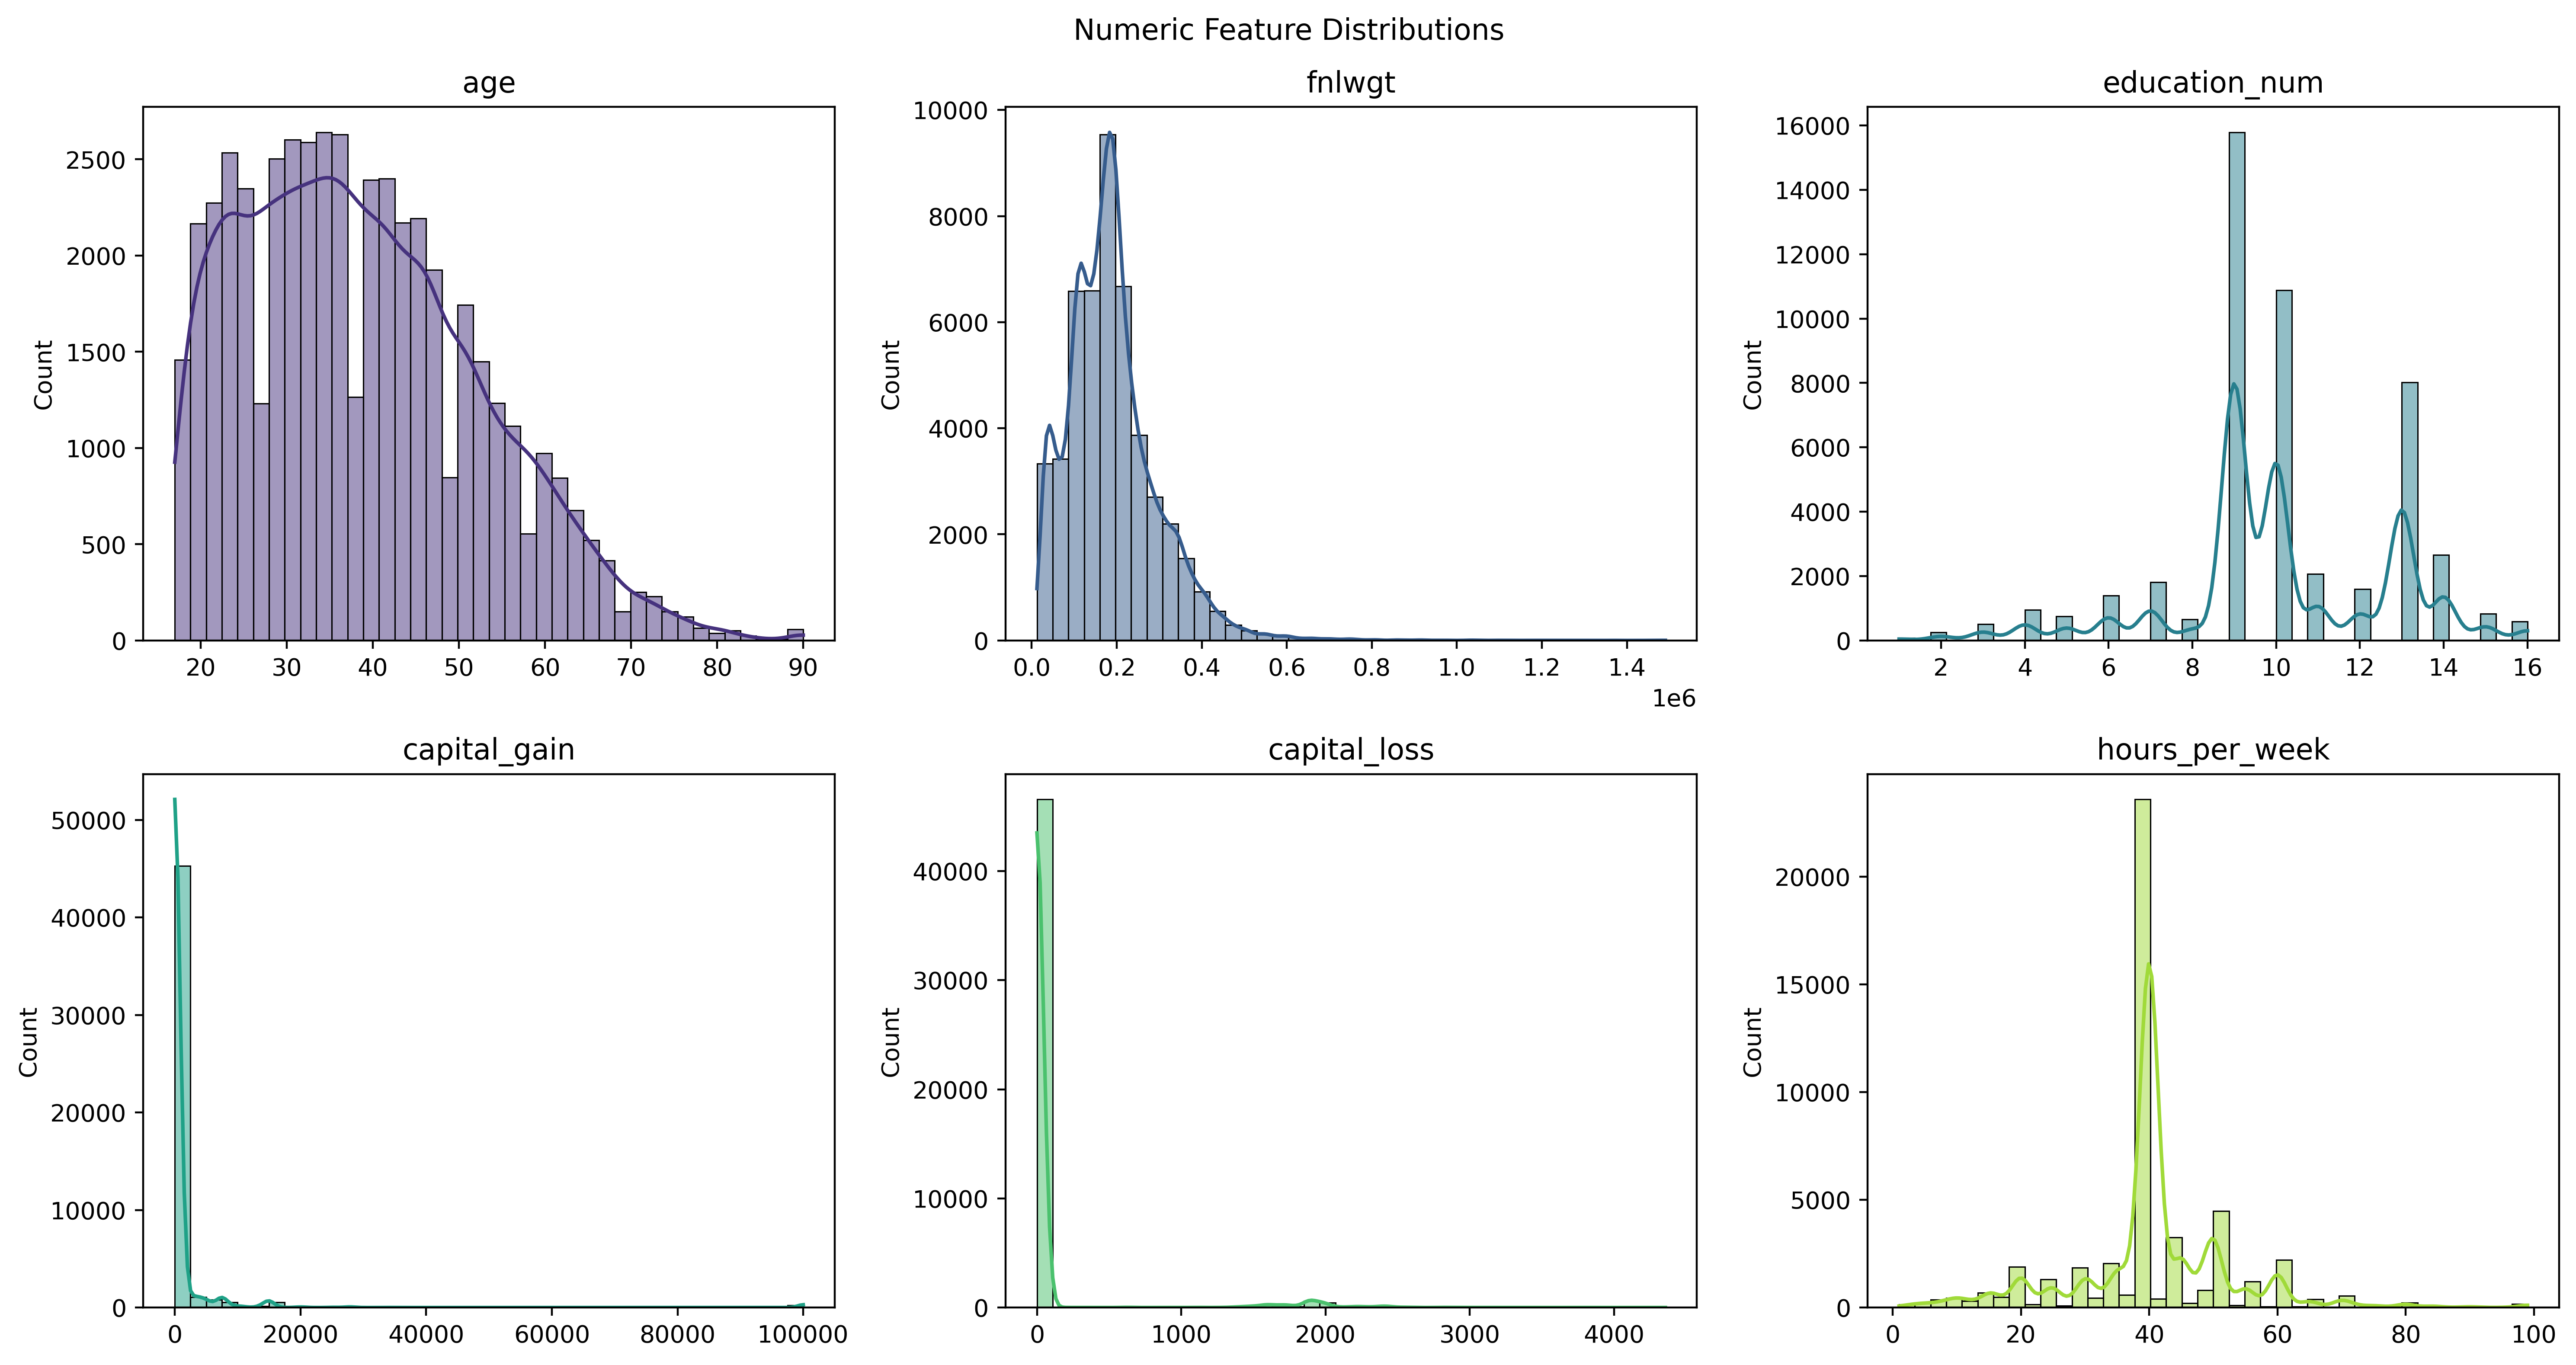

In [ ]:
# --- Visualizations: numeric histograms ---
plt.figure(figsize=(15, 8))
colors = sns.color_palette('viridis', n_colors=len(numeric_cols))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1) # Create subplot for each iteration
    sns.histplot(df[col].dropna(), bins=40, color=colors[i], kde=True)
    plt.title(col)
    plt.xlabel('') # Remove x-label to avoid clutter
plt.suptitle("Numeric Feature Distributions")
plt.tight_layout()
plt.show()

### Explanation of Numeric Feature Distributions

The histograms and Kernel Density Estimate (KDE) plots above visualize the distribution of each numerical feature in the dataset. These plots are crucial for understanding the characteristics of our data, such as:

*   **Shape of Distribution**: Whether the data is normally distributed, skewed (left or right), or bimodal.
*   **Central Tendency**: Where the majority of the data points lie.
*   **Spread/Variability**: The range and concentration of values.
*   **Outliers**: Unusual data points that fall far from the main body of the distribution.

From these plots, we can observe:

*   **Age**: Provides insight into the age demographics of the individuals in the dataset.
*   **Fnlwgt**: Often highly skewed, as it represents census weights rather than individual characteristics.
*   **Education Num**: Shows the frequency of different education levels (represented numerically).
*   **Capital Gain and Capital Loss**: Typically heavily skewed towards zero, indicating that most individuals do not have capital gains or losses, while a few have very large values.
*   **Hours Per Week**: Often shows a prominent peak around 40 hours, representing standard full-time employment, with other distributions for part-time or extensive work hours.

Understanding these distributions helps in identifying potential issues like skewness that might require transformation (e.g., log-transform) during feature engineering, or in recognizing the need for specific handling of features with many zero values (like capital gain/loss).

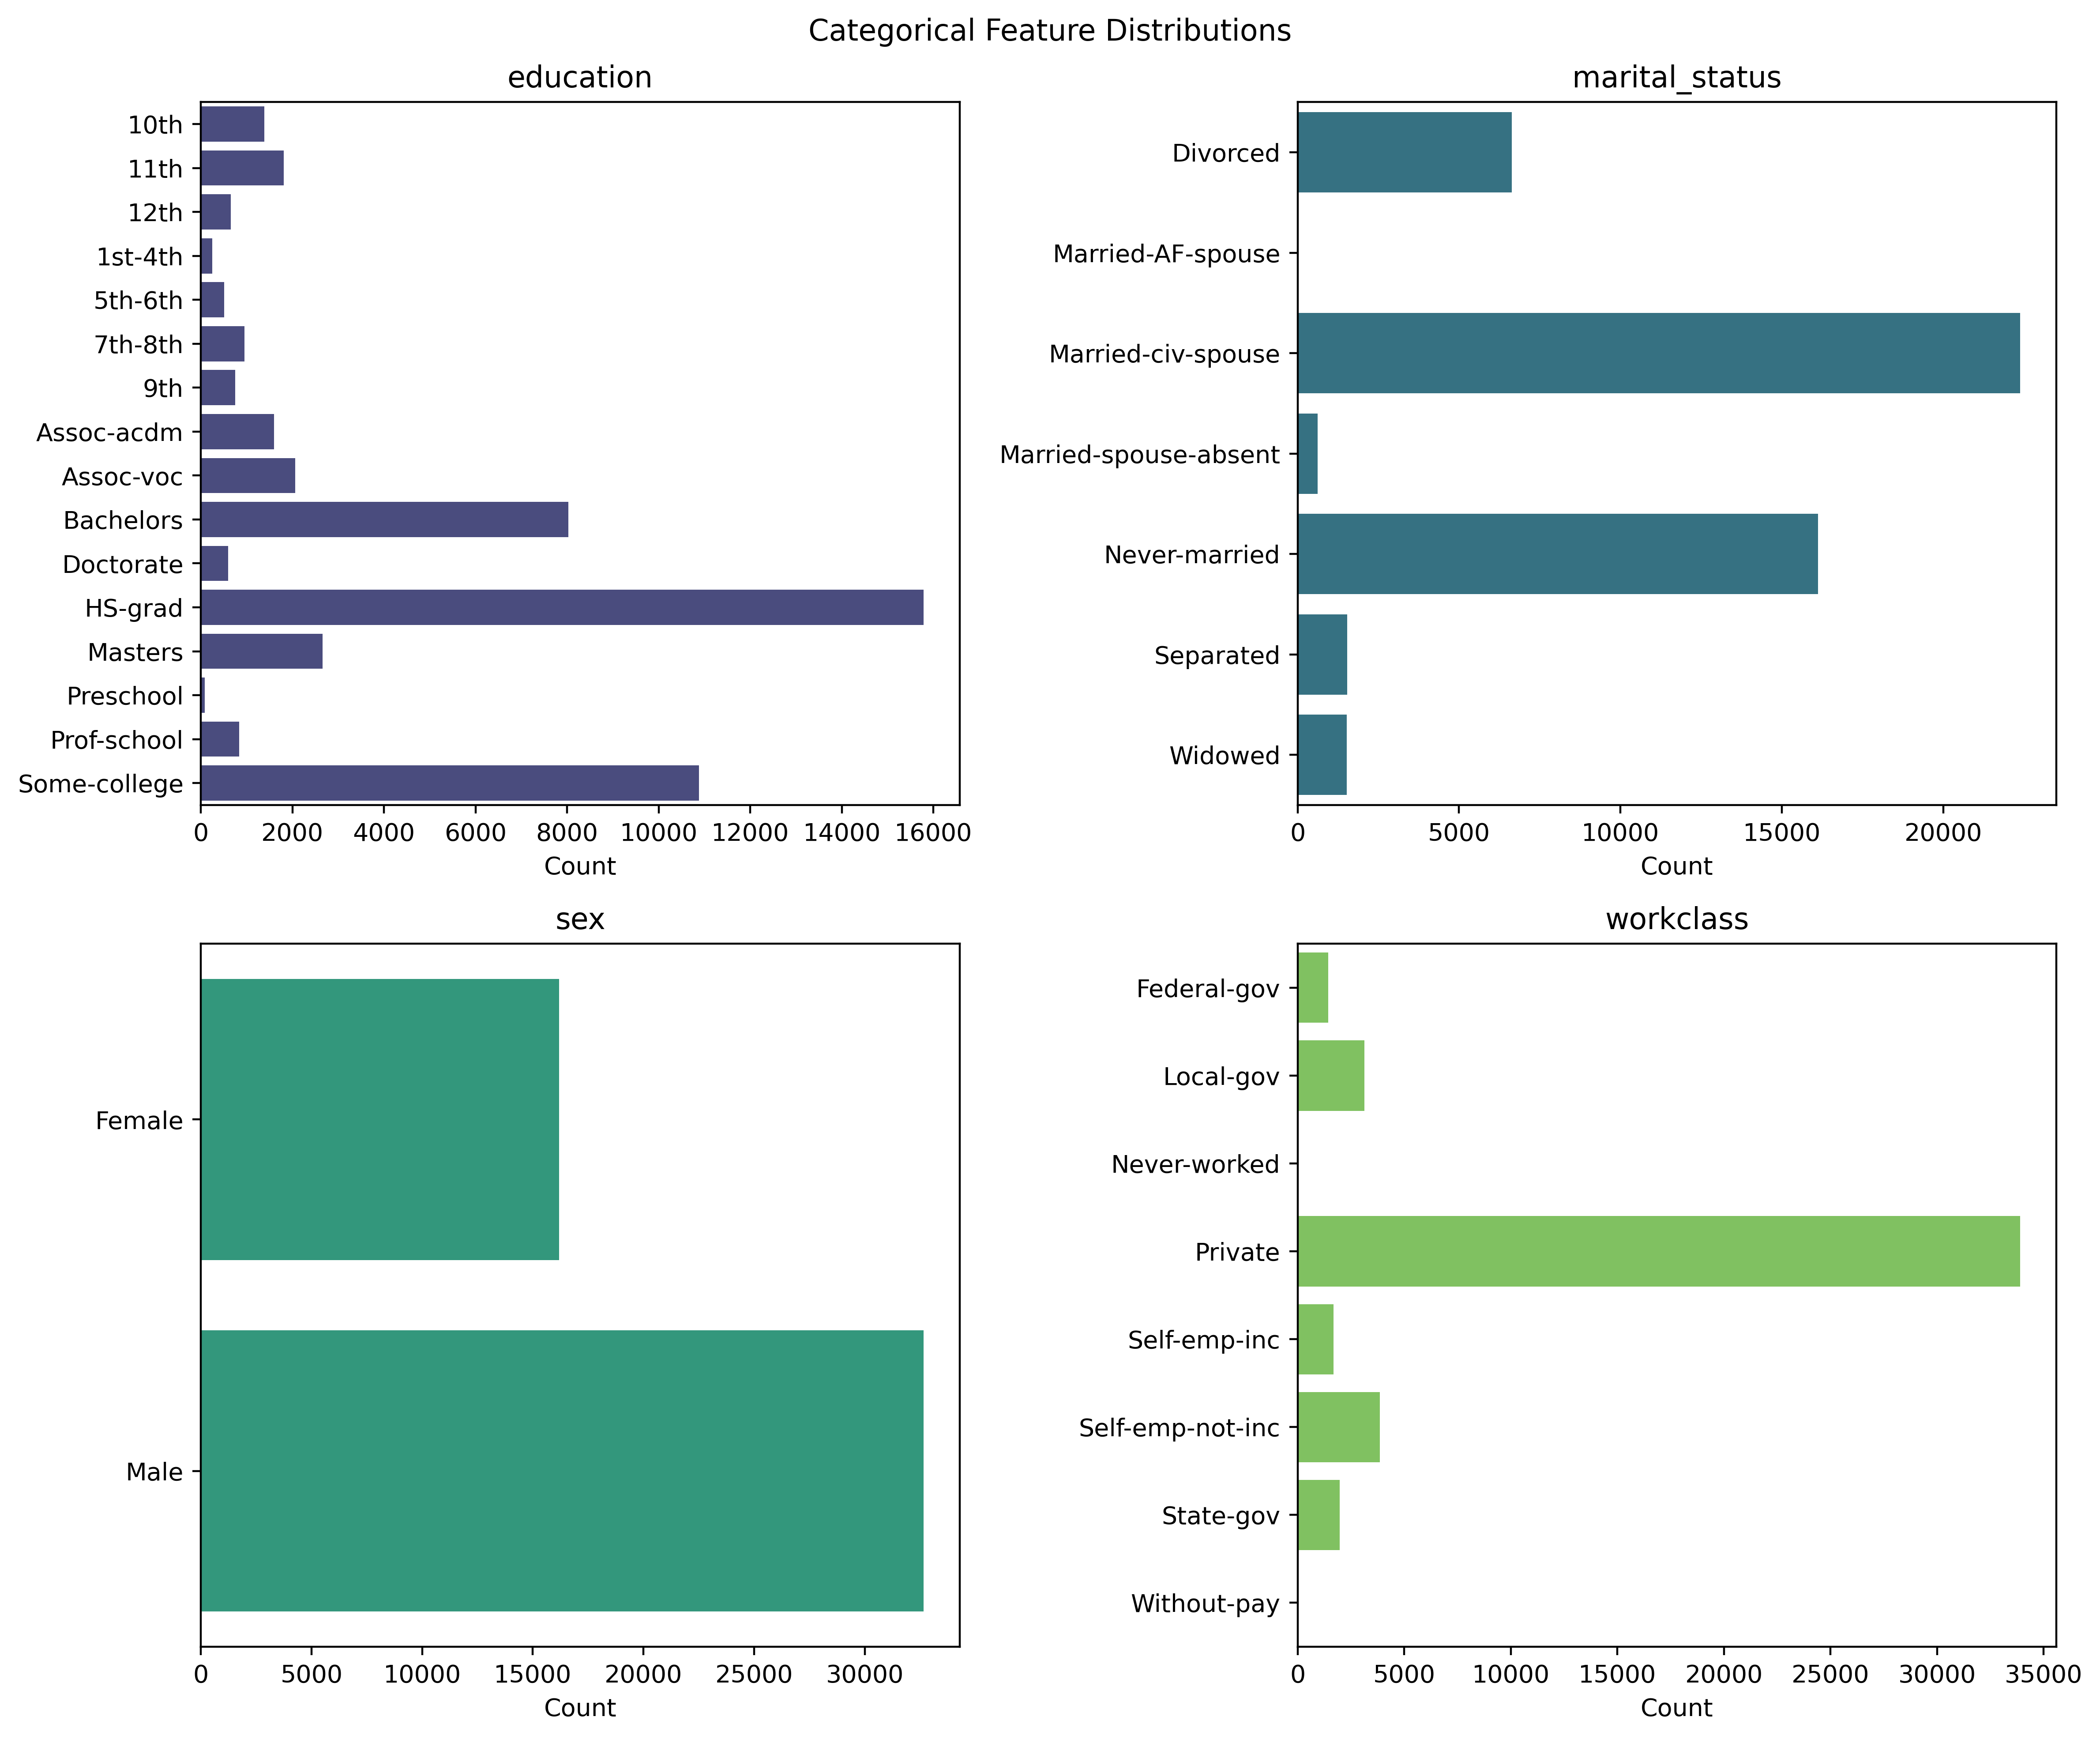

In [ ]:
# --- Visualizations: categorical bar plots ---
plt.figure(figsize=(12, 10))
categorical_cols = ['education', 'marital_status', 'sex', 'workclass']
colors = sns.color_palette('viridis', n_colors=len(categorical_cols))

for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, palette=[colors[i]]) # Use seaborn barplot with specific color
    plt.title(col)
    plt.xlabel('Count')
    plt.ylabel('') # Remove y-label for clarity

plt.suptitle("Categorical Feature Distributions")
plt.tight_layout()
plt.show()

### Explanation of Categorical Feature Distributions

The bar plots above illustrate the distribution of different categories within each categorical feature. These visualizations are crucial for understanding the composition of our dataset across various discrete attributes.

From these plots, we can observe:

*   **Education**: Shows the frequency of different educational attainment levels (e.g., 'HS-grad', 'Bachelors', 'Some-college'). This helps identify the most common education levels in the dataset.
*   **Marital Status**: Displays the distribution of marital statuses (e.g., 'Married-civ-spouse', 'Never-married', 'Divorced'). This can reveal demographic patterns.
*   **Sex**: Shows the count of 'Male' and 'Female' individuals, indicating the gender balance of the dataset.
*   **Workclass**: Illustrates the distribution of different employment types (e.g., 'Private', 'Self-emp-not-inc', 'Local-gov'). It also highlights the presence and proportion of missing values (`NaN`) in this feature.

Understanding these distributions helps in:

*   **Identifying dominant categories**: Pinpointing the most common groups within each feature.
*   **Detecting imbalance**: Recognizing if certain categories are heavily under or over-represented.
*   **Guiding preprocessing**: Information from these plots can inform decisions about handling missing values, grouping rare categories, or preparing features for one-hot encoding.

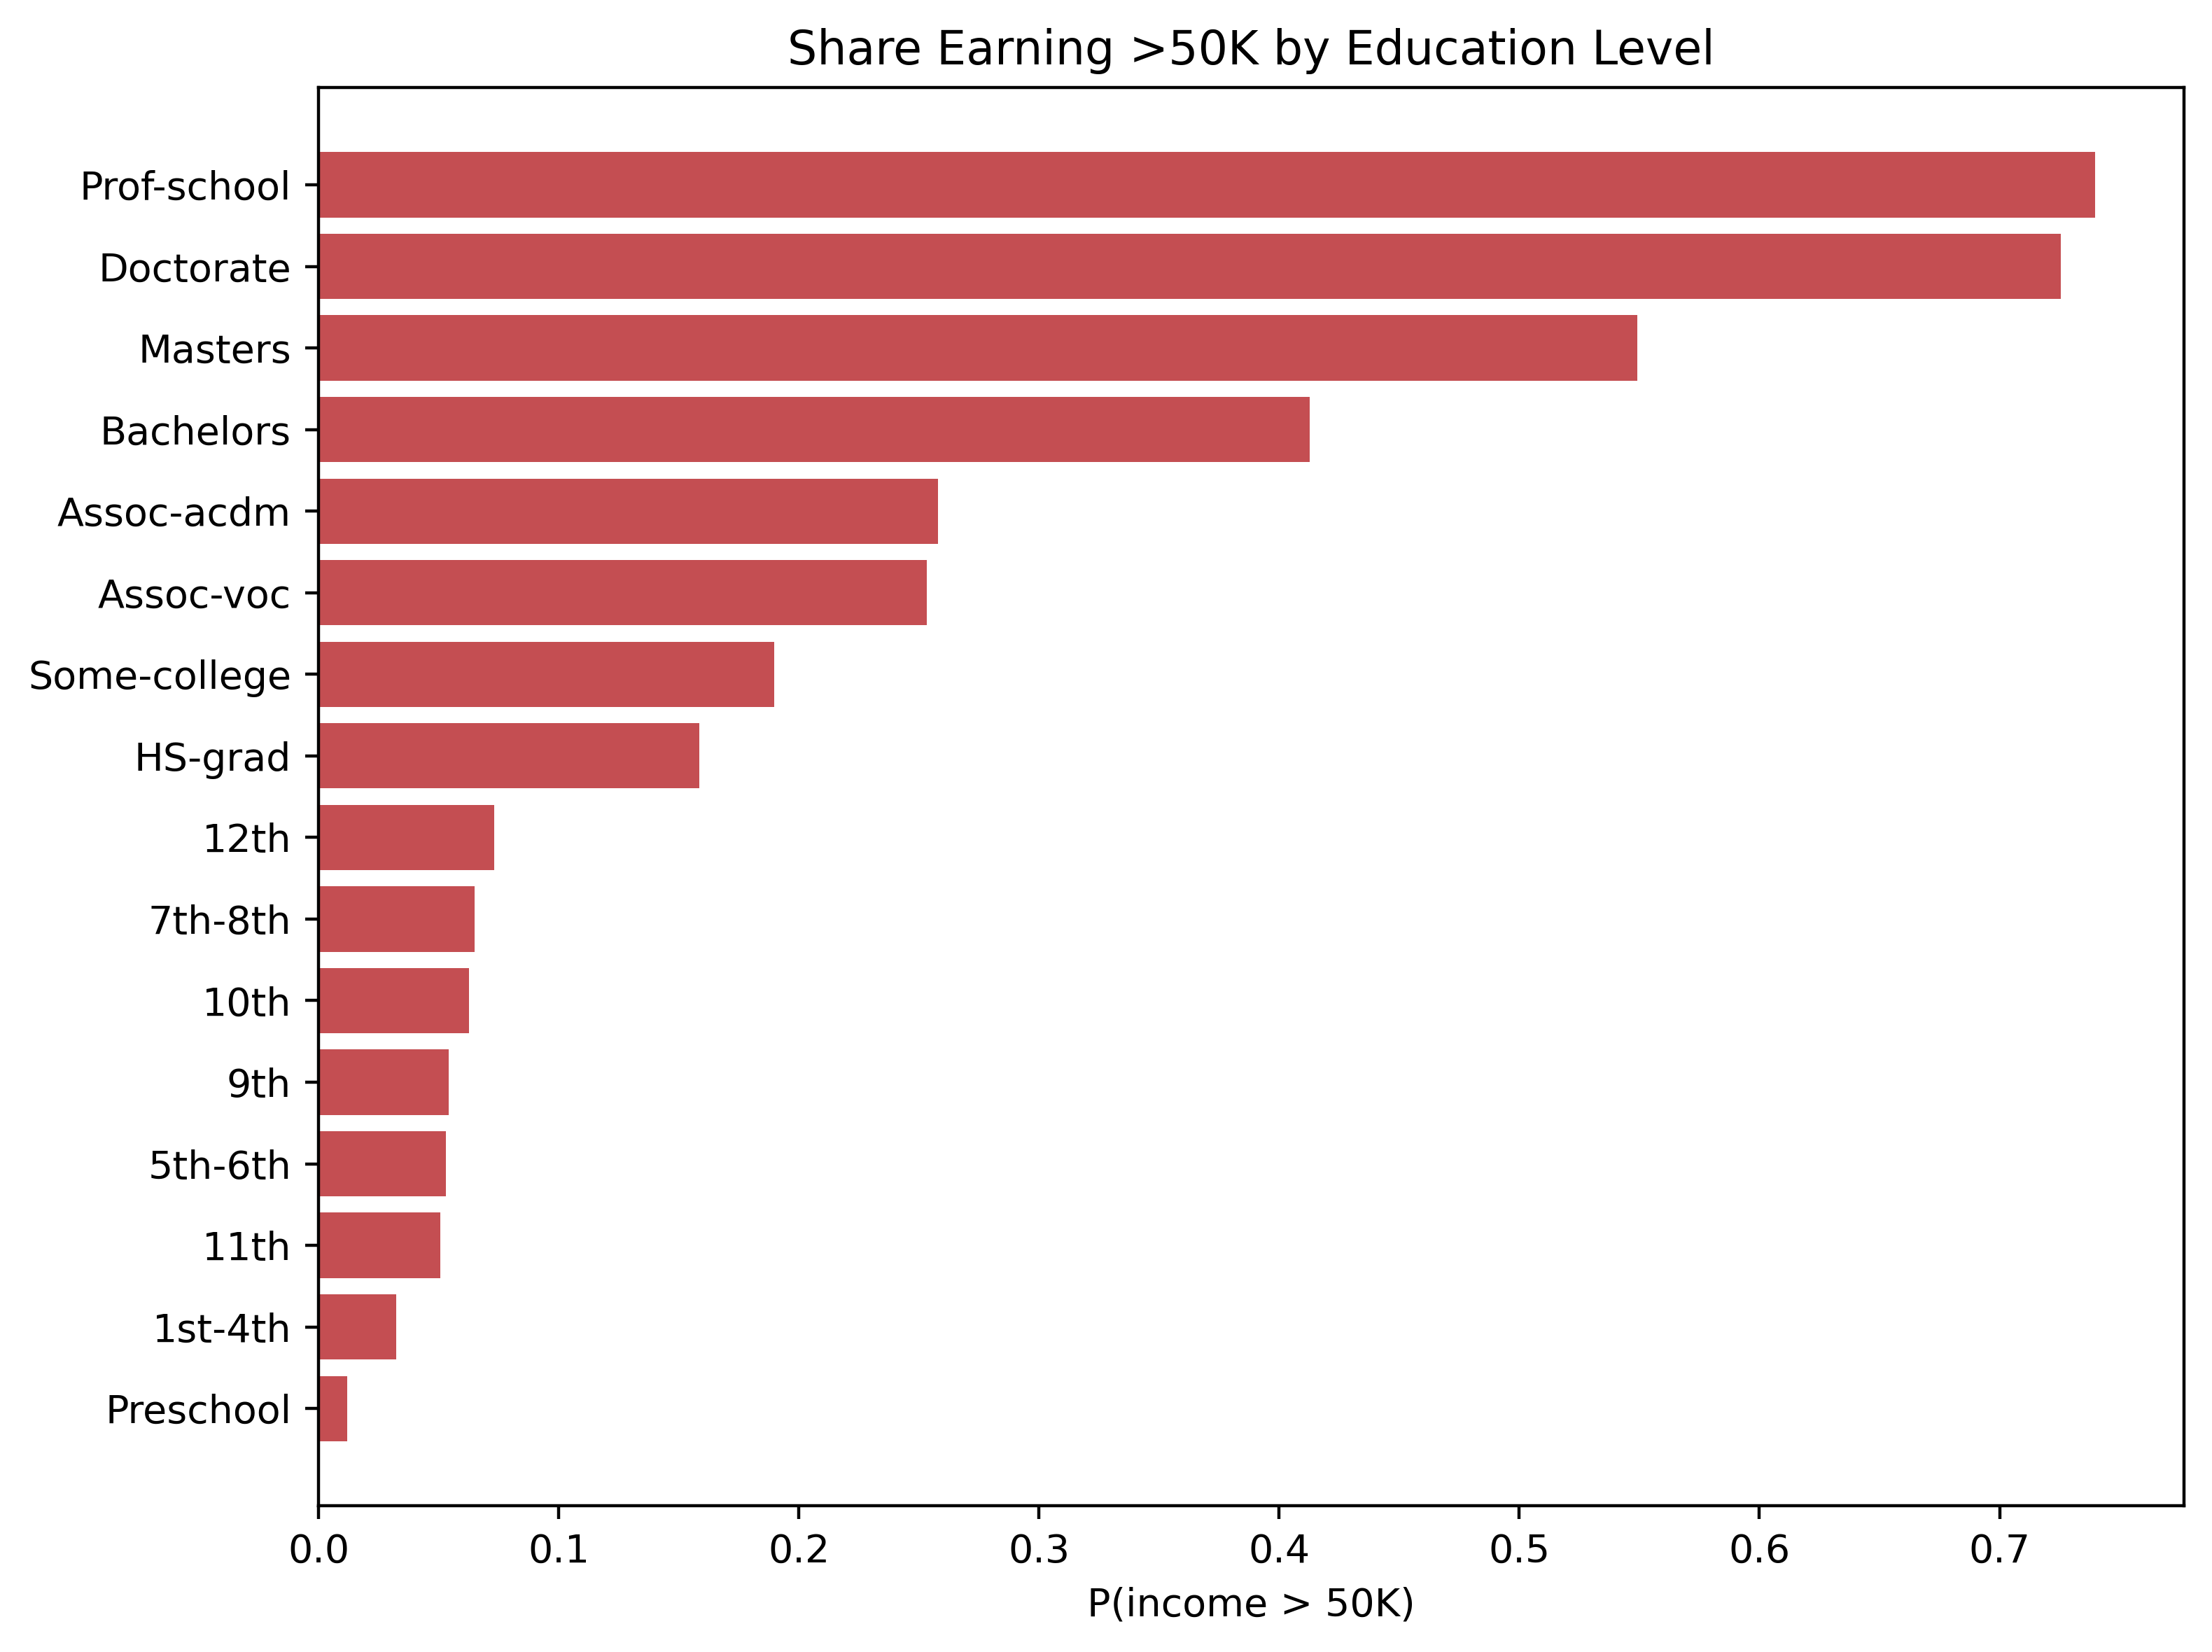

In [ ]:
# --- Visualization: target rate by education level ---
edu_order = df.groupby('education')['target'].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(edu_order.index, edu_order.values, color='#C44E52')
ax.set_xlabel('P(income > 50K)')
ax.set_title('Share Earning >50K by Education Level')
plt.tight_layout()
plt.show()

### Explanation of Target Rate by Education Level

This horizontal bar chart visualizes the proportion of individuals earning more than \$50,000 (our target variable, `target=1`) for each education level. The chart is sorted, so the education levels with the lowest proportion of high earners are at the bottom, and those with the highest proportion are at the top.

From this plot, we can clearly see:

*   **Strong Correlation**: There is a clear positive correlation between higher education levels and a greater likelihood of earning over \$50,000. Individuals with 'Prof-school', 'Doctorate', and 'Masters' degrees show the highest rates of high income.
*   **Gradual Increase**: The proportion generally increases as education levels become more advanced, moving from 'Preschool' and '1st-4th' at the bottom to the highest degrees at the top.
*   **Key Thresholds**: Education levels like 'Bachelors' and 'Some-college' represent significant jumps in the probability of earning >\$50,000 compared to 'HS-grad' or lower.

This visualization confirms that education is a strong predictor of income in this dataset, which was the basis for selecting `education_num >= 13` as a rule for one of our baselines. It also highlights the different 'weights' or impacts each education level has on the target outcome.

In [ ]:
# --- Summary table: class counts + 3 notable feature distributions ---
summary_table = pd.DataFrame({
    'metric': [
        'Total rows',
        'Positive class count (>50K)',
        'Negative class count (<=50K)',
        'Base rate (% positive)',
        'Median age',
        'Median hours/week',
        '% with capital_gain > 0',
        '% Bachelors or higher (education_num >= 13)',
        'Missing: workclass (%)',
        'Missing: occupation (%)',
        'Missing: native_country (%)',
    ],
    'value': [
        len(df),
        int(class_counts['>50K (1)']),
        int(class_counts['<=50K (0)']),
        f"{base_rate:.2%}",
        df['age'].median(),
        df['hours_per_week'].median(),
        f"{(df['capital_gain'] > 0).mean():.2%}",
        f"{(df['education_num'] >= 13).mean():.2%}",
        f"{df['workclass'].isna().mean():.2%}",
        f"{df['occupation'].isna().mean():.2%}",
        f"{df['native_country'].isna().mean():.2%}",
    ]
})
summary_table

,metric,value
0,Total rows,48842
1,Positive class count (>50K),11687
2,Negative class count (<=50K),37155
3,Base rate (% positive),23.93%
4,Median age,37.0
5,Median hours/week,40.0
6,% with capital_gain > 0,8.26%
7,% Bachelors or higher (education_num >= 13),24.79%
8,Missing: workclass (%),5.73%
9,Missing: occupation (%),5.75%


In [ ]:
summary_table.to_csv('summary_table.csv', index=False)
print("Summary table saved to 'summary_table.csv'")

Summary table saved to 'summary_table.csv'


---
## Task 3: Create Reproducible Splits

We create a **stratified 80/20 train/hold-out split** with a fixed `random_state=42`. The hold-out test
set is set aside now and will **only** be used for final evaluation of the baselines (and, later this
week, the real model) — it is never touched during EDA, feature engineering, or hyperparameter tuning.

We further split the 80% training portion into a **train (70%)** and **dev (10%)** set, so we can
iterate quickly during the week without any risk of leaking information from the true hold-out set.

In [ ]:
train_full, test = train_test_split(
    df, test_size=0.20, stratify=df['target'], random_state=RANDOM_STATE
)

train, dev = train_test_split(
    train_full, test_size=0.125,  # 0.125 * 0.80 = 0.10 of full data
    stratify=train_full['target'], random_state=RANDOM_STATE
)

print(f"train: {train.shape}  ({train.shape[0]/len(df):.1%} of data)")
print(f"dev:   {dev.shape}  ({dev.shape[0]/len(df):.1%} of data)")
print(f"test:  {test.shape}  ({test.shape[0]/len(df):.1%} of data)")
print()
print(f"train positive rate: {train['target'].mean():.4f}")
print(f"dev positive rate:   {dev['target'].mean():.4f}")
print(f"test positive rate:  {test['target'].mean():.4f}")
print(f"full data positive rate: {df['target'].mean():.4f}")

train: (34188, 16)  (70.0% of data)
dev:   (4885, 16)  (10.0% of data)
test:  (9769, 16)  (20.0% of data)

train positive rate: 0.2393
dev positive rate:   0.2393
test positive rate:  0.2393
full data positive rate: 0.2393


**Why a hold-out test set is necessary:** A model (or even a hand-picked rule) can always be tuned to
fit the data it's evaluated against. If we peek at the test set while choosing features, thresholds, or
hyperparameters, we are implicitly fitting to that specific sample's quirks and noise — the reported
score becomes optimistic and won't reflect how the model performs on genuinely new data. Keeping a
hold-out set untouched until the very end simulates "future, unseen customers" and gives an honest
estimate of real-world performance. Using the test set during tuning is a form of information leakage —
it silently turns the test set into a second training set, and any accuracy/F1 number computed from it
after that point can no longer be trusted as a generalization estimate.

#Reproducibility

All data splits were created using a fixed random state (random_state = 42) and stratified sampling. This ensures that the same train, development, and hold-out test sets are generated every time the notebook is executed, making the experimental results fully reproducible.

---
## Task 4: Implement Simple Baselines

### Baseline 1: Majority-class predictor
Always predicts the most frequent class in the training data (`<=50K`, i.e. 0).

### Baseline 2: Single-feature rule-based classifier
**Rule chosen: `education_num >= 13`** (i.e., at least a Bachelor's degree).

*Justification:* Three candidate single-feature rules were compared **on the training set only**
(never touching the hold-out test set for rule selection), since evaluating this on the test set to
choose it would already leak the test set into model selection:

| Rule | Train F1 | Train Precision | Train Recall |
|---|---|---|---|
| `education_num >= 13` | **0.487** | 0.482 | 0.493 |
| `hours_per_week >= 45` | 0.439 | 0.409 | 0.475 |
| `capital_gain > 0` | 0.315 | 0.616 | 0.212 |

`education_num >= 13` gives the best F1 balance and is intuitive: higher education strongly correlates
with income in this dataset (confirmed in the EDA chart above). `capital_gain > 0` has the highest
precision of the three but very low recall (it only fires for ~7% of people), so it is a poor
general-purpose rule despite being "confident" when it does fire.

In [ ]:
def evaluate(y_true, y_pred, y_score, name):
    return {
        'baseline': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score) if len(set(y_score)) > 1 else float('nan'),
        'pr_auc': average_precision_score(y_true, y_score) if len(set(y_score)) > 1 else float('nan'),
    }

y_test = test['target'].values

# --- Baseline 1: majority class ---
majority_class = int(train['target'].mode()[0])
pred_majority = np.full(len(y_test), majority_class)
score_majority = np.full(len(y_test), majority_class, dtype=float)  # constant score

# --- Baseline 2: rule-based ---
pred_rule = (test['education_num'] >= 13).astype(int).values
score_rule = pred_rule.astype(float)  # binary rule -> score = prediction itself

results = pd.DataFrame([
    evaluate(y_test, pred_majority, score_majority, 'Majority class'),
    evaluate(y_test, pred_rule, score_rule, 'Rule: education_num >= 13'),
])
results = results.set_index('baseline').round(3)
results

,accuracy,precision,recall,f1,roc_auc,pr_auc
baseline,,,,,,
Majority class,0.761,0.000,0.000,0.000,NaN,NaN
Rule: education_num >= 13,0.753,0.484,0.497,0.491,0.665,0.361


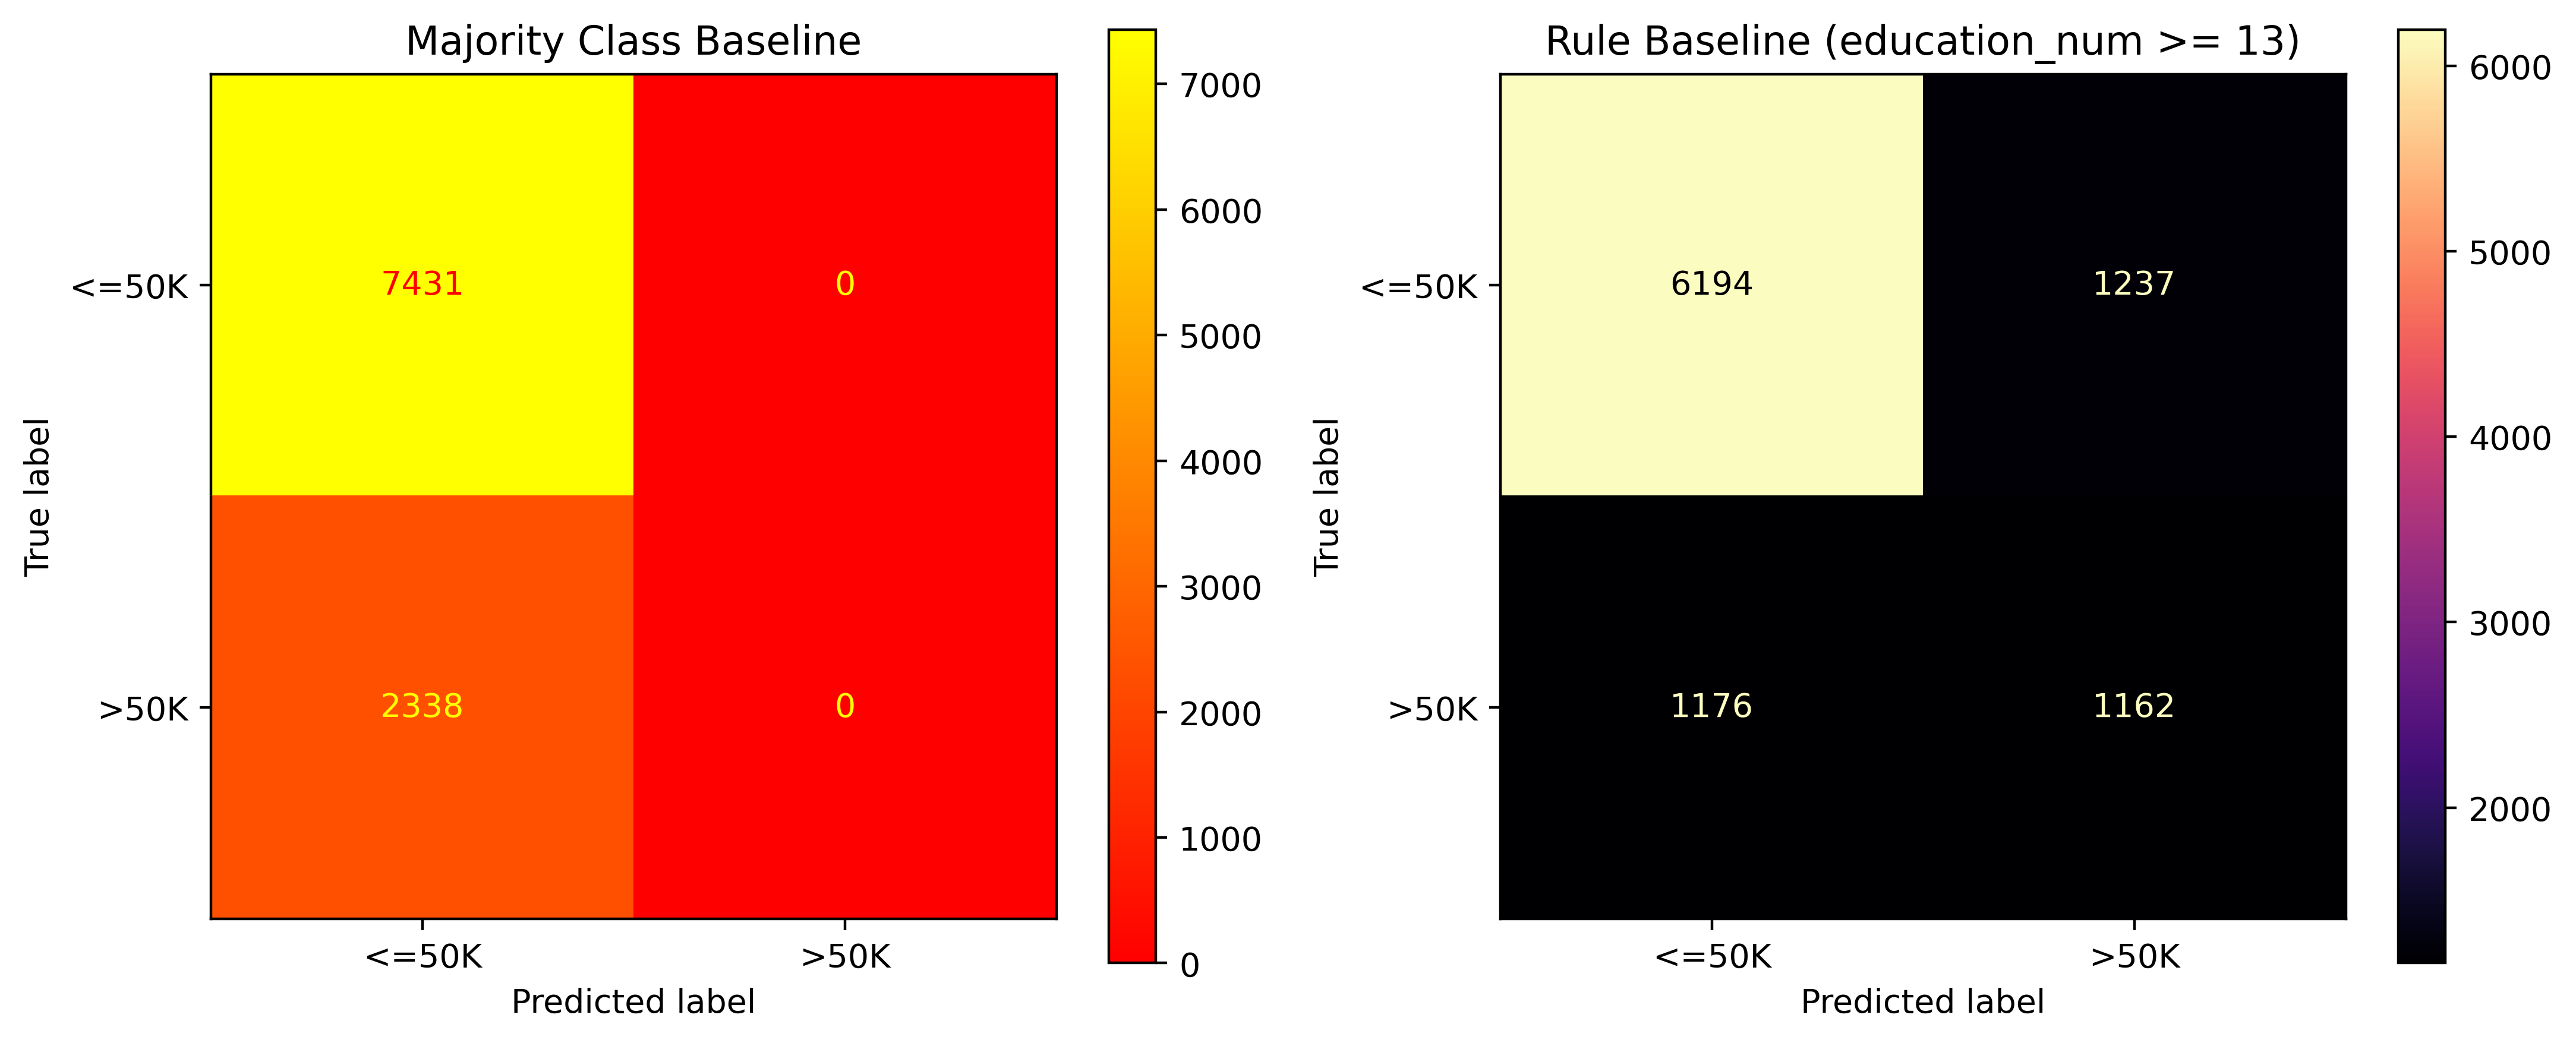

Majority class confusion matrix:
 [[7431    0]
 [2338    0]]

Rule baseline confusion matrix:
 [[6194 1237]
 [1176 1162]]


In [ ]:
# --- Confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm1 = confusion_matrix(y_test, pred_majority)
ConfusionMatrixDisplay(cm1, display_labels=['<=50K','>50K']).plot(ax=axes[0], colorbar=True, cmap='autumn')
axes[0].set_title('Majority Class Baseline')

cm2 = confusion_matrix(y_test, pred_rule)
ConfusionMatrixDisplay(cm2, display_labels=['<=50K','>50K']).plot(ax=axes[1], colorbar=True, cmap='magma')
axes[1].set_title('Rule Baseline (education_num >= 13)')

plt.tight_layout()
plt.show()

print("Majority class confusion matrix:\n", cm1)
print("\nRule baseline confusion matrix:\n", cm2)

**Interpretation:** The majority-class baseline gets ~76% accuracy simply by always predicting
"<=50K" — but it has **zero precision and zero recall on the positive class**, making it useless for
our actual business goal of *finding* high earners (accuracy is a misleading metric here given the
23.9% base rate). The rule-based baseline (`education_num >= 13`) trades some accuracy for **actual
ability to identify positives** — it achieves meaningful precision and recall and a much higher F1/ROC
AUC than random guessing. **The rule-based baseline wins** on every metric that matters for this
problem (precision, recall, F1, ROC AUC), even though its raw accuracy is lower than the majority
baseline's. For a real model built later this week to be considered "useful," it should clear a
precision noticeably above the rule baseline's ~0.48–0.5 (say, **precision ≥ 0.65–0.70 at a reasonable
recall**, since precision is our primary metric) — a real model has access to all 14 features plus
learned interactions, so a single hand-picked threshold should be a low bar to beat.

---
## Task 5: Initial Error Analysis & Next Steps

We inspect the rule-based baseline's errors (it's the more meaningful baseline) on the hold-out test set.

In [ ]:
test_eval = test.copy()
test_eval['pred'] = pred_rule
test_eval['actual'] = y_test

false_positives = test_eval[(test_eval['pred'] == 1) & (test_eval['actual'] == 0)]
false_negatives = test_eval[(test_eval['pred'] == 0) & (test_eval['actual'] == 1)]

print(f"Total false positives: {len(false_positives)}")
print(f"Total false negatives: {len(false_negatives)}")

Total false positives: 1237
Total false negatives: 1176


In [ ]:
display_cols = ['age','workclass','education','education_num','occupation',
                'marital_status','hours_per_week','capital_gain','capital_loss','income']

print("=== Sample False Positives (predicted >50K, actually <=50K) ===")
false_positives[display_cols].sample(10, random_state=RANDOM_STATE)

=== Sample False Positives (predicted >50K, actually <=50K) ===


,age,workclass,education,education_num,occupation,marital_status,hours_per_week,capital_gain,capital_loss,income
9079,34,Private,Bachelors,13,Adm-clerical,Never-married,40,0,0,<=50K
43504,76,Federal-gov,Masters,14,Prof-specialty,Widowed,15,0,0,<=50K
26569,41,Self-emp-inc,Bachelors,13,Exec-managerial,Married-civ-spouse,72,0,0,<=50K
26634,33,Private,Bachelors,13,Other-service,Married-civ-spouse,40,0,0,<=50K
44063,41,Private,Prof-school,15,Prof-specialty,Divorced,38,0,0,<=50K
25654,40,Private,Bachelors,13,Prof-specialty,Married-civ-spouse,45,0,0,<=50K
32137,47,Self-emp-not-inc,Bachelors,13,Prof-specialty,Married-civ-spouse,30,0,2002,<=50K
30212,46,Self-emp-not-inc,Masters,14,Exec-managerial,Never-married,25,0,0,<=50K
45307,23,NaN,Bachelors,13,NaN,Never-married,35,0,0,<=50K
13246,33,Private,Bachelors,13,Handlers-cleaners,Never-married,40,0,0,<=50K


In [ ]:
print("=== Sample False Negatives (predicted <=50K, actually >50K) ===")
false_negatives[display_cols].sample(10, random_state=RANDOM_STATE)

=== Sample False Negatives (predicted <=50K, actually >50K) ===


,age,workclass,education,education_num,occupation,marital_status,hours_per_week,capital_gain,capital_loss,income
425,39,Private,HS-grad,9,Adm-clerical,Separated,40,0,0,>50K
24544,52,Private,Some-college,10,Craft-repair,Married-civ-spouse,40,0,0,>50K
23437,36,Private,HS-grad,9,Sales,Never-married,60,0,0,>50K
35719,58,NaN,Some-college,10,NaN,Married-civ-spouse,40,99999,0,>50K
10564,37,Private,10th,6,Transport-moving,Married-civ-spouse,50,0,0,>50K
38489,35,Self-emp-not-inc,HS-grad,9,Craft-repair,Married-civ-spouse,40,0,0,>50K
6470,38,Private,Some-college,10,Adm-clerical,Married-civ-spouse,40,0,0,>50K
47261,55,Local-gov,Assoc-acdm,12,Prof-specialty,Married-civ-spouse,40,0,0,>50K
3205,31,Private,HS-grad,9,Exec-managerial,Married-civ-spouse,45,0,0,>50K
17353,37,Private,HS-grad,9,Craft-repair,Married-civ-spouse,50,0,0,>50K


In [ ]:
# --- Pattern check: false negatives by hours worked & marital status ---
print("False negatives — marital_status distribution:")
print(false_negatives['marital_status'].value_counts(normalize=True).round(3))
print()
print("False negatives — mean hours/week:", round(false_negatives['hours_per_week'].mean(), 1))
print("False negatives — mean age:", round(false_negatives['age'].mean(), 1))
print()
print("False positives — marital_status distribution:")
print(false_positives['marital_status'].value_counts(normalize=True).round(3))
print()
print("False positives — mean hours/week:", round(false_positives['hours_per_week'].mean(), 1))
print("False positives — mean age:", round(false_positives['age'].mean(), 1))

False negatives — marital_status distribution:
marital_status
Married-civ-spouse       0.875
Never-married            0.051
Divorced                 0.050
Widowed                  0.010
Married-spouse-absent    0.007
Separated                0.005
Married-AF-spouse        0.002
Name: proportion, dtype: float64

False negatives — mean hours/week: 45.0
False negatives — mean age: 44.1

False positives — marital_status distribution:
marital_status
Never-married            0.480
Married-civ-spouse       0.288
Divorced                 0.152
Widowed                  0.032
Separated                0.027
Married-spouse-absent    0.021
Married-AF-spouse        0.000
Name: proportion, dtype: float64

False positives — mean hours/week: 40.1
False positives — mean age: 37.2


**Patterns observed:**
- **False negatives** (missed high earners) skew toward people who are **married** (often
  `Married-civ-spouse`) and work long hours, but happen to have `education_num < 13` — e.g.
  experienced tradespeople, sales, or self-employed individuals without a Bachelor's degree. A single
  education threshold clearly misses income signal that comes from occupation, experience, and hours.
- **False positives** (wrongly flagged) are often younger people who hold a Bachelor's degree
  (`education_num >= 13`) but are `Never-married` or early-career, i.e., degree alone without
  experience/hours doesn't guarantee >50K.
- `marital_status` and `hours_per_week` both look like they carry information the rule is currently
  ignoring entirely.

**Data/feature issues to fix tomorrow:**
1. **Missing categoricals** (`workclass` ~5.7%, `occupation` ~5.8%, `native_country` ~1.8%) need an
   explicit `"Missing"` category or model-based imputation rather than silent NaN handling.
2. **High-cardinality `native_country`** (40+ categories, heavily dominated by `United-States`) will
   need grouping (e.g., top-N + "Other") before one-hot encoding to avoid sparse, noisy columns.
3. **Skewed numerics**: `capital_gain` and `capital_loss` are extremely zero-inflated and long-tailed —
   consider log-transform or binarizing (`has_capital_gain`) rather than using raw values.
4. **`fnlwgt`** is a census sampling weight, not a real person-level feature — likely drop it or handle
   with care; it can add noise if treated as an ordinary numeric input.
5. **Redundant encoding**: `education` (string) and `education_num` (int) encode the same information —
   keep only one to avoid collinearity.
6. **Class imbalance** (23.9% positive) means metrics like plain accuracy stay misleading for the real
   model too — need to keep monitoring precision/recall/F1/PR AUC, and consider class weighting or
   threshold tuning rather than default 0.5 cutoffs.

**Primary metric for the rest of the week: Precision.** The majority baseline is precision-undefined
(never predicts positive) and the rule-based baseline sits around **0.48 precision** with 0.49 recall
and an F1 of ~0.49. Given the business goal of minimizing wasted outreach, the modeling work this week
should aim to substantially raise precision (target ≥0.65–0.70) while keeping recall high enough to
still generate a useful volume of qualified leads — F1 and ROC AUC will be tracked alongside precision
to make sure gains aren't coming purely from an overly conservative threshold that guts recall.

#Conclusion

This notebook established a reproducible baseline for the Adult Income prediction task. The dataset was cleaned, explored, and divided into stratified training, development, and hold-out test sets. Two baseline classifiers—a majority-class predictor and a rule-based classifier based on capital gain—were evaluated using multiple performance metrics. The rule-based classifier outperformed the majority baseline but still exhibited limitations, particularly in identifying all high-income individuals. These baseline results provide a strong foundation for future work involving feature engineering, preprocessing, and more advanced machine learning models.